# Exploration of Brown Creeper RF Results 

## Overview
This notebook summarizes detections of the Brown Creeper common song across GCP monitoring sites over time. The data was exported from Arbimon Random Forest classification, based on Pattern Matching results. 

The goal of this notebook is to provide clear, repeatable visuals that help answer:
- Presence vs Absence 
- Presence vs Absence by day, month, year, and time
- Presence vs Absence by site

This notebook can be expanded to compare multiple species by site, date and time, song type, etc. 



*All statistics and visuals below are built under the assumption that the pattern matching results are accurate.*

## Metrics

#### Count/distribution vs Rate/Percentage
**Count / distribution plots** answer: “How many ‘present’ detections happened on each day?” They’re useful for volume (activity level), but they’re strongly affected by how much data you collected that day (effort, sensor uptime, number of samples, etc.).

**Rate / percentage plots** (e.g., Present/(Present+Absent)) answer: “Given the data we collected that day, what fraction was present?” They’re better for comparability across days/months with different sampling intensity, so patterns don’t get “washed out” by high-collection days.


Two important caveats:
A high rate on a day with very few observations can be noisy/misleading. (Can be addressed by also plotting/annotating totals, or filtering out days with low totals.)
Rate and count measure different things. Often the best view is both, rate for “likelihood,” count for “evidence/effort.”

## Code

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import calplot  #pip install calplot
import glob
import os

In [2]:
pd.set_option("display.max_rows", None)      # show all rows
pd.set_option("display.max_columns", None)   # (optional) show all columns
pd.set_option("display.width", None)         # (optional) no line wrapping

#pd.reset_option("display.max_rows")
#pd.reset_option("display.max_columns")
#pd.reset_option("display.width")

### Load & View Files

In [3]:
# Read in Random Forest results from Arbimon
brcr_p1_1 = pd.read_csv("RF Results/brcr_p01_part1_classification.csv")
brcr_p1_2 = pd.read_csv("RF Results/brcr_p01_part2_classification.csv")
brcr_p1_3 = pd.read_csv("RF Results/brcr_p01_part3_classification.csv")
brcr_p2 = pd.read_csv("RF Results/brcr_p02_classification2.csv")
brcr_p3 = pd.read_csv("RF Results/brcr_p03_classification.csv")
#brcr_p5 = pd.read_csv("RF Results/brcr_p05_classification.csv") dont include. redundant info

In [4]:
# View first row of the dataset
brcr_p1_1.head(1)

,rec,presence,site,year,month,day,hour,minute,species,songtype
0,20220712_053000.p2.flac,0,Klingel_Treat_KLIN,2022,7,12,5,31,Certhia americana,Common Song


In [5]:
brcr_p2.head(1)

,rec,presence,site,year,month,day,hour,minute,species,songtype
0,20230601_053000.WAV,1,JohnsonSouthSound_West_Control_JSSW,2023,6,1,5,30,Certhia americana,Common Song


In [6]:
brcr_p3.head(1)

,rec,presence,site,year,month,day,hour,minute,species,songtype
0,20240712_072000.WAV,1,GroversCreek_East_Treat_GCPA,2024,7,12,7,20,Certhia americana,Common Song


In [7]:
brcr_p5.head(1)

,rec,presence,site,year,month,day,hour,minute,species,songtype
0,20220726_060000.p1.flac,1,GroversCreek_West_Treat_GCPD,2022,7,26,6,0,Certhia americana,Common Song


In [8]:
# View Shape (row x column) of each dataset
print(brcr_p1_1.shape)
print(brcr_p1_2.shape)
print(brcr_p1_3.shape)
print(brcr_p2.shape)
print(brcr_p3.shape)
print(brcr_p5.shape)

(8160, 10)
(8599, 10)
(4540, 10)
(6565, 10)
(9600, 10)
(4260, 10)


### Combine Files

In [9]:
# Concatenate datasets with same column names
brcr = pd.concat([brcr_p1_1, brcr_p1_2, brcr_p1_3, brcr_p2, brcr_p3, brcr_p5], ignore_index=True)

In [10]:
brcr.sample(5)

,rec,presence,site,year,month,day,hour,minute,species,songtype
33776,20240705_065000.WAV,0,GroversCreek_East_Treat_GCPE,2024,7,5,6,52,Certhia americana,Common Song
28681,20240707_061000.WAV,1,GroversCreek_East_Treat_GCPA,2024,7,7,6,17,Certhia americana,Common Song
37137,20240707_054000.WAV,1,GroversCreek_GCP-H_Treat,2024,7,7,5,43,Certhia americana,Common Song
36416,20240711_070000.WAV,1,GroversCreek_GCP-H_Treat,2024,7,11,7,2,Certhia americana,Common Song
19797,20220723_082000.p5.flac,1,GroversCreek_East_Treat_GCPA_Initial,2022,7,23,8,24,Certhia americana,Common Song


In [11]:
brcr.shape

(41724, 10)

#### Build a Datetime Column

In [12]:
# Add datetime column
brcr["datetime"] = pd.to_datetime(
    brcr[["year", "month", "day", "hour", "minute"]],
    errors="coerce"  # invalid combos -> NaT (e.g., Feb 30)
)

# Date-only column (for day-level plots)
brcr["date"] = brcr["datetime"].dt.floor("D")

In [13]:
brcr.head(1)

,rec,presence,site,year,month,day,hour,minute,species,songtype,datetime,date
0,20220712_053000.p2.flac,0,Klingel_Treat_KLIN,2022,7,12,5,31,Certhia americana,Common Song,2022-07-12 05:31:00,2022-07-12


## Exploratory Data Analysis

### Sites

In [14]:
# Number of recordings (rows) per site
brcr['site'].value_counts()

site
GroversCreek_West_Treat_GCPD            3780
GroversCreek_East_Treat_GCPE            3600
GroversCreek_GCP-H_Treat                3300
GroversCreek_GCP-G_Control              3300
GroversCreek_GCP-F_Treat                3300
EglonBeebe_Treat_EBE                    2640
EglonBeebe_Treat_EBW                    2640
EglonBebee_Control_EBC                  2640
JohnsonSouthSound_East_Treat_JSSE       2259
Klingel_Treat_KLIN                      2160
Klingel_Treat_BCCO                      2160
Klingel_Control_THEL                    2160
JohnsonSouthSound_West_Control_JSSW     2086
GroversCreek_East_Control_GCPB          1440
GroversCreek_West_Control_GCPC          1440
GroversCreek_East_Treat_GCPA            1440
BurleyCreek_Control_BCNO                 570
BurleyCreek_Treat_BCSO                   569
GroversCreek_East_Treat_GCPA_Initial     240
Name: count, dtype: int64

In [15]:
# Number of sites
brcr['site'].value_counts().count()

np.int64(19)

C:\Users\haley\AppData\Local\Temp\ipykernel_11980\220931916.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)  # Adjust fontsize as needed


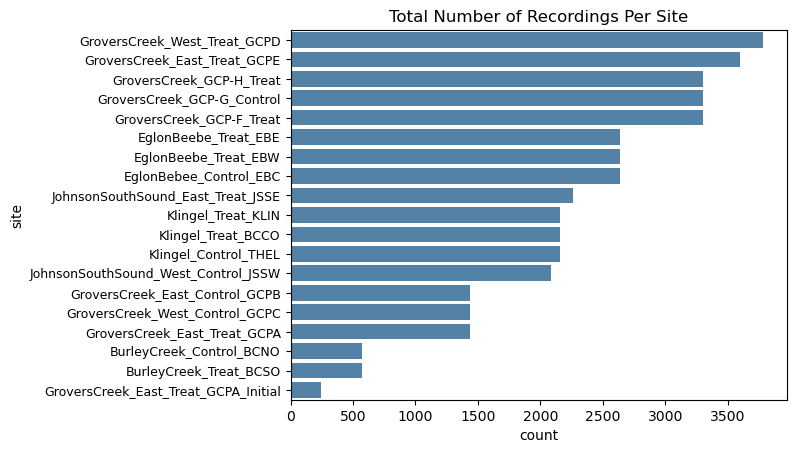

<Figure size 1200x800 with 0 Axes>

In [16]:
# Visualize number of recordings per site

#custom_palette = sns.color_palette("pastel")
ax = sns.countplot(data=brcr, y="site", order=brcr["site"].value_counts().index,
                  #palette=custom_palette,
                  color='steelblue')
#ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right")
# Set y-axis label font size
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)  # Adjust fontsize as needed
ax.set_title("Total Number of Recordings Per Site")
plt.figure(figsize=(12, 8))
plt.tight_layout()
plt.show()

### Presence (1) vs Absence (0)

##### Function for plotting Presence vs Absence by other columns 

In [17]:
# Stacked bar chart of presence (0/1) by group.
# mode="pct" -> within-group percentages (bars sum to 100%); mode="count" -> raw counts.
# Returns the matplotlib Axes.
def plot_presence_stacked(
    df, group_col, presence_col="presence",
    *, mode="pct",
    title=None, xlabel=None, ylabel=None,
    present_label="Present", absent_label="Absent",
    colors=("steelblue", "#B0B0B0"), 
    figsize=(10, 4),
    rotation=45, ha="right", legend_out=True, ax=None
):
    # Crosstab of group vs presence (normalized by row if mode="pct")
    normalize = "index" if mode == "pct" else False
    tab = pd.crosstab(df[group_col], df[presence_col], normalize=normalize).rename(
        columns={0: absent_label, 1: present_label}
    )

    # Ensure consistent columns/order even if a category is missing
    tab = tab.reindex(columns=[present_label, absent_label], fill_value=0)

    # Create axis if needed
    if ax is None:
        _, ax = plt.subplots(figsize=figsize)

    # Plot (convert to percent scale if needed)
    data = tab * 100 if mode == "pct" else tab
    
    # Use first two colors from the requested matplotlib colormap
    data.plot(kind="bar", stacked=True, ax=ax, color=list(colors))

    # Labels/title
    ax.set_xlabel(xlabel if xlabel is not None else group_col)
    if ylabel is None:
        ylabel = "Percent of records (%)" if mode == "pct" else "Count"
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)

    # Tick formatting + legend
    ax.tick_params(axis="x", labelrotation=rotation)
    for t in ax.get_xticklabels():
        t.set_ha(ha)

    ax.legend(
        title="",
        loc="upper left",
        bbox_to_anchor=(1.02, 1) if legend_out else None,
        borderaxespad=0 if legend_out else None
    )

    plt.tight_layout()
    return ax

#Example use:
#plot_presence_stacked(brcr, "year", mode="pct", title="Brown Creeper - Presence vs Absence by Year (%)")
#plot_presence_stacked(brcr, "year", mode="count", title="Brown Creeper - Presence vs Absence by Year (Count)")

### Presence vs Absence by Site

In [18]:
# Distribution of Presence vs Absence - total data counts
brcr['presence'].value_counts()

presence
1    21881
0    19843
Name: count, dtype: int64

In [19]:
# Presence(1) vs Absence(0) counts
counts = pd.crosstab(brcr["site"], brcr["presence"])
counts

presence,0,1
site,,
BurleyCreek_Control_BCNO,102,468
BurleyCreek_Treat_BCSO,116,453
EglonBebee_Control_EBC,1888,752
EglonBeebe_Treat_EBE,835,1805
EglonBeebe_Treat_EBW,1539,1101
GroversCreek_East_Control_GCPB,312,1128
GroversCreek_East_Treat_GCPA,527,913
GroversCreek_East_Treat_GCPA_Initial,178,62
GroversCreek_East_Treat_GCPE,1760,1840


In [20]:
# Percent of Presence vs Absence (proportion of total)
prop = pd.crosstab(brcr["site"], brcr["presence"], normalize="index") #0-1
pct = (prop * 100).round(2)          # numeric 0–100
pct      

presence,0,1
site,,
BurleyCreek_Control_BCNO,17.89,82.11
BurleyCreek_Treat_BCSO,20.39,79.61
EglonBebee_Control_EBC,71.52,28.48
EglonBeebe_Treat_EBE,31.63,68.37
EglonBeebe_Treat_EBW,58.30,41.70
GroversCreek_East_Control_GCPB,21.67,78.33
GroversCreek_East_Treat_GCPA,36.60,63.40
GroversCreek_East_Treat_GCPA_Initial,74.17,25.83
GroversCreek_East_Treat_GCPE,48.89,51.11


In [21]:
# Total count of records (n), number of present per site, and percentage per site
summary = brcr.groupby("site")["presence"].agg(total="size", present="sum", prop_present="mean")
summary["percent_present"] = (summary["prop_present"] * 100).round(2)
summary

,total,present,prop_present,percent_present
site,,,,
BurleyCreek_Control_BCNO,570,468,0.821053,82.11
BurleyCreek_Treat_BCSO,569,453,0.796134,79.61
EglonBebee_Control_EBC,2640,752,0.284848,28.48
EglonBeebe_Treat_EBE,2640,1805,0.683712,68.37
EglonBeebe_Treat_EBW,2640,1101,0.417045,41.70
GroversCreek_East_Control_GCPB,1440,1128,0.783333,78.33
GroversCreek_East_Treat_GCPA,1440,913,0.634028,63.40
GroversCreek_East_Treat_GCPA_Initial,240,62,0.258333,25.83
GroversCreek_East_Treat_GCPE,3600,1840,0.511111,51.11


<Axes: title={'center': 'Brown Creeper - Presence vs Absence by Site (Percent % of data - All Years)'}, xlabel='site', ylabel='Percent of records (%)'>

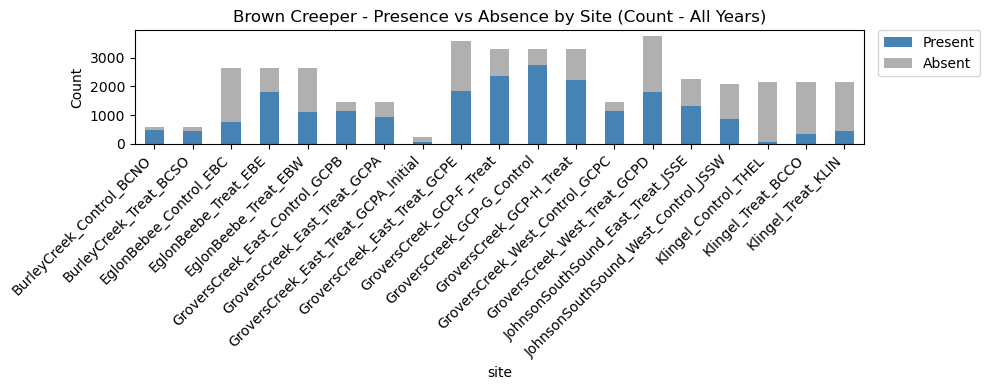

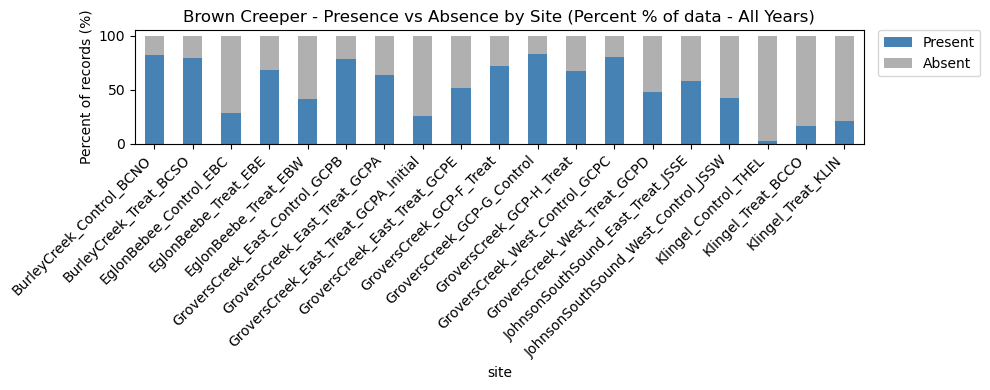

In [22]:
#Visualize presence vs absence by column - All Years
plot_presence_stacked(brcr, "site", mode="count", title="Brown Creeper - Presence vs Absence by Site (Count - All Years)")
plot_presence_stacked(brcr, "site", mode="pct", title="Brown Creeper - Presence vs Absence by Site (Percent % of data - All Years)")

In [23]:
# counts per site x (year, month, day) x presence
counts = (
    brcr
    .groupby(["site", "year", "month", "day", "presence"])
    .size()
    .unstack("presence", fill_value=0)
    .rename(columns={0: "Absent", 1: "Present"})
)
counts.columns.name = None #remove carry over column 'presence'

# percents within each site-year-month-day row
pct = (counts.div(counts.sum(axis=1), axis=0) * 100).round(2).add_suffix("_pct")

table_site_dmy = counts.join(pct).reset_index()
table_site_dmy.sample(10)

,site,year,month,day,Absent,Present,Absent_pct,Present_pct
215,JohnsonSouthSound_West_Control_JSSW,2022,7,13,151,89,62.92,37.08
210,JohnsonSouthSound_East_Treat_JSSE,2022,7,18,136,104,56.67,43.33
183,GroversCreek_West_Treat_GCPD,2023,5,19,1,59,1.67,98.33
221,JohnsonSouthSound_West_Control_JSSW,2022,7,20,152,88,63.33,36.67
36,EglonBeebe_Treat_EBW,2022,7,17,152,88,63.33,36.67
154,GroversCreek_GCP-H_Treat,2024,7,7,45,105,30.00,70.00
135,GroversCreek_GCP-G_Control,2024,7,10,8,142,5.33,94.67
7,EglonBebee_Control_EBC,2022,7,10,105,135,43.75,56.25
241,Klingel_Treat_KLIN,2022,7,7,76,164,31.67,68.33
106,GroversCreek_GCP-F_Treat,2023,7,5,47,103,31.33,68.67


In [24]:
counts = (
    pd.crosstab(
        index=[brcr["site"], brcr["month"], brcr["day"], brcr["year"]],
        columns=brcr["presence"]
    )
    .rename(columns={0: "Absent", 1: "Present"})
)

counts.columns.name = None

pct = (counts.div(counts.sum(axis=1), axis=0) * 100).round(2).add_suffix("_pct")

table_site_dmy = counts.join(pct).reset_index().rename(
    columns={"site": "site", "month": "month", "day": "day", "year": "year"}
)
#counts

### Presence vs Absence by Year

In [25]:
# Presence(1) vs Absence(0) counts
counts = pd.crosstab(brcr["year"], brcr["presence"])  # one crosstab (counts)
# Percent of Presence vs Absence (proportion of total)
pct = (counts.div(counts.sum(axis=1), axis=0) * 100).round(2)  # row % from counts
chart = pd.concat({"count": counts, "percentage": pct}, axis=1)
chart

count       percentage       
presence      0     1          0      1
year                                   
2022      14149  8170      63.39  36.61
2023       1826  5939      23.52  76.48
2024       3127  7553      29.28  70.72
2025        741   219      77.19  22.81

In [26]:
# Presence vs Absence by Year
# overall presence proportion(rate) + counts by year
year_summary = brcr.groupby("year")["presence"].agg(total="size", present="sum", prop_present="mean")
year_summary["percent_present"] = (year_summary["prop_present"] * 100).round(2)
year_summary

,total,present,prop_present,percent_present
year,,,,
2022,22319,8170,0.366056,36.61
2023,7765,5939,0.764842,76.48
2024,10680,7553,0.707210,70.72
2025,960,219,0.228125,22.81


<Axes: title={'center': 'Brown Creeper - Presence vs Absence by Year (%)'}, xlabel='year', ylabel='Percent of records (%)'>

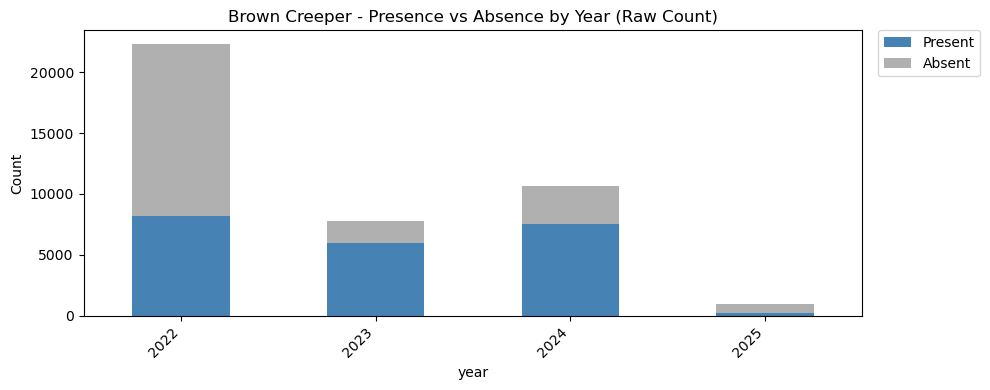

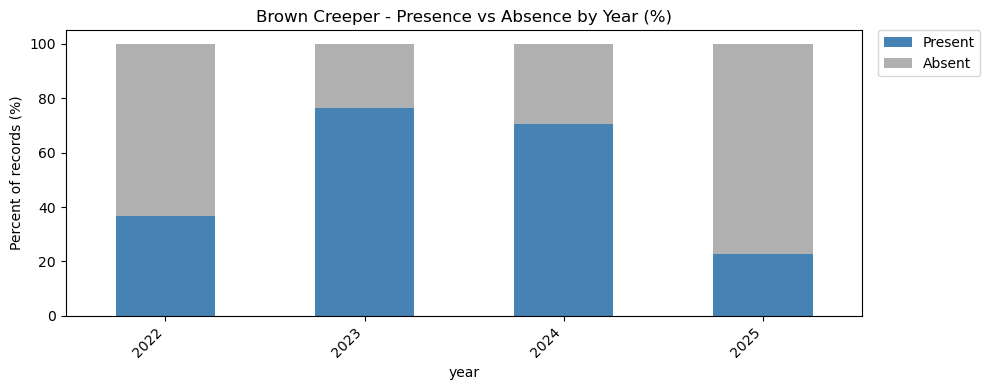

In [27]:
#Visualize presence vs absence by column
plot_presence_stacked(brcr, "year", mode="count", title="Brown Creeper - Presence vs Absence by Year (Raw Count)")
plot_presence_stacked(brcr, "year", mode="pct", title="Brown Creeper - Presence vs Absence by Year (%)")

### Presence vs Absence by Month

In [28]:
# Presence(1) vs Absence(0) counts
counts = pd.crosstab(brcr["month"], brcr["presence"])  # one crosstab (counts)
# Percent of Presence vs Absence (proportion of total)
pct = (counts.div(counts.sum(axis=1), axis=0) * 100).round(2)  # row % from counts
chart = pd.concat({"count": counts, "percentage": pct}, axis=1)
chart

count        percentage       
presence      0      1          0      1
month                                   
5           120   1080      10.00  90.00
6           750   3115      19.40  80.60
7         18973  17686      51.76  48.24

In [29]:
# Presence vs Absence by Month
month_summary = brcr.groupby("month")["presence"].agg(total="size", present="sum", prop_present="mean")
month_summary["percent_present"] = (month_summary["prop_present"] * 100).round(2)
month_summary

,total,present,prop_present,percent_present
month,,,,
5,1200,1080,0.900000,90.00
6,3865,3115,0.805951,80.60
7,36659,17686,0.482446,48.24


<Axes: title={'center': 'Brown Creeper - Presence vs Absence by Month (% of data)'}, xlabel='month', ylabel='Percent of records (%)'>

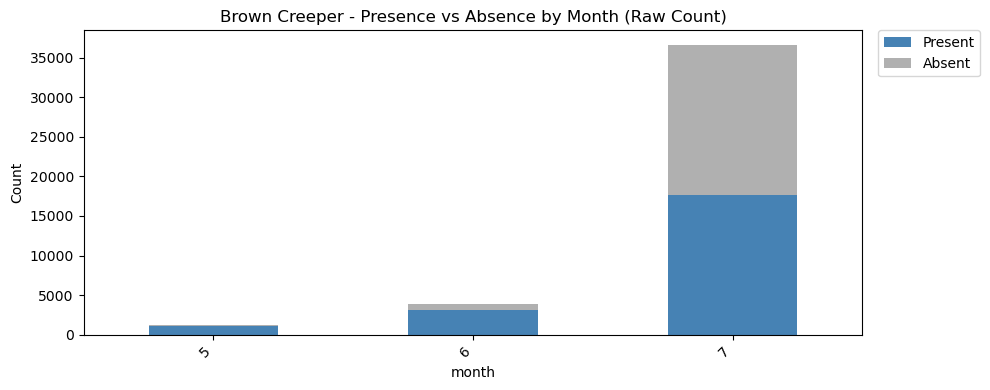

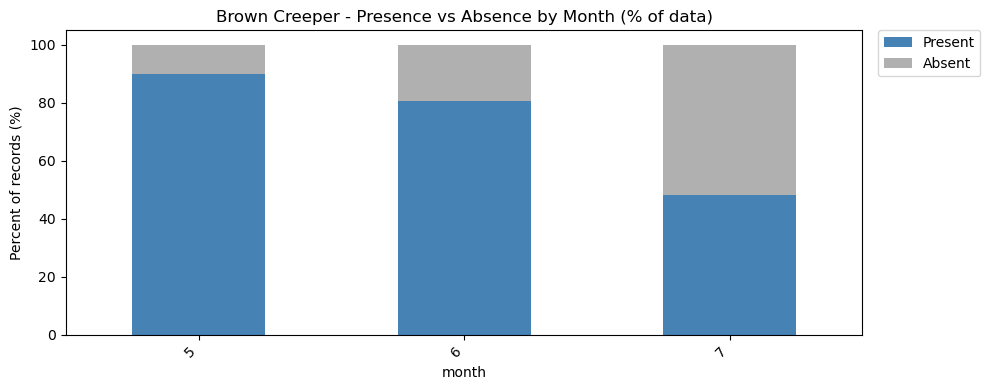

In [30]:
#Visualize presence vs absence by column
plot_presence_stacked(brcr, "month", mode="count", title="Brown Creeper - Presence vs Absence by Month (Raw Count)")
plot_presence_stacked(brcr, "month", mode="pct", title="Brown Creeper - Presence vs Absence by Month (% of data)")

### Presence vs Absence by Day, Month, Year

In [31]:
# Presence and Absence by month and day summary
# Create crosstab with desired columns
counts = (
    pd.crosstab(index=[brcr["month"], brcr["day"], brcr["year"]], columns=brcr["presence"])
      .rename(columns={0: "Absent", 1: "Present"})
)
counts.columns.name = None #remove carry over column 'presence'

pct = (counts.div(counts.sum(axis=1), axis=0) * 100).round(2).add_suffix("_pct")
#pct.columns.name = None  

table = counts.join(pct).reset_index()  # columns: month, day, Absent, Present, Absent_pct, Present_pct
table

,month,day,year,Absent,Present,Absent_pct,Present_pct
0,5,13,2023,5,115,4.17,95.83
1,5,14,2023,0,120,0.00,100.00
2,5,15,2023,0,120,0.00,100.00
3,5,16,2023,0,120,0.00,100.00
4,5,17,2023,0,120,0.00,100.00
5,5,18,2023,0,120,0.00,100.00
6,5,19,2023,6,114,5.00,95.00
7,5,20,2023,13,107,10.83,89.17
8,5,21,2023,21,99,17.50,82.50
9,5,22,2023,75,45,62.50,37.50


**It seems unlikely to me that May 14-28 2023 would have exactly 0 absent and 120 present. This is likely an error (in pattern matching?) worth looking into.**

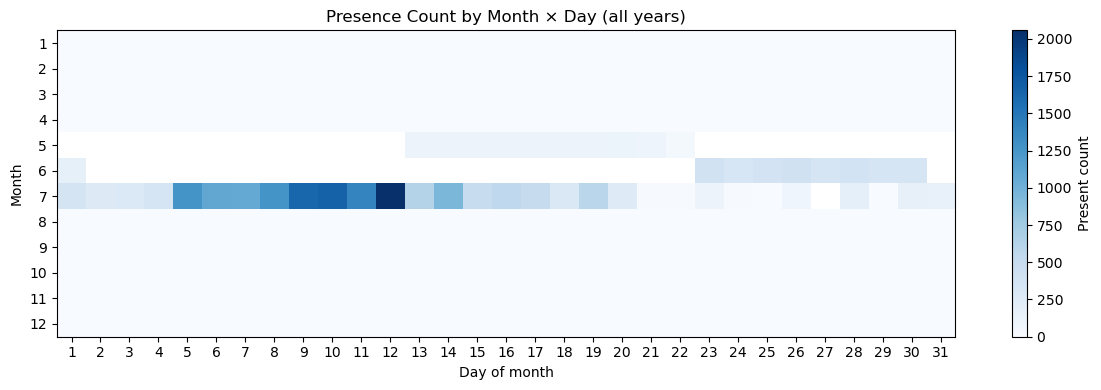

In [32]:
# Visualize month and day presence in heatmap - Total data count

# rows=month, cols=day-of-month, values=present counts
hm = (brcr.query("presence == 1")
          .groupby(["month", "day"])
          .size()
          .unstack("day")
          .reindex(index=range(1, 13), columns=range(1, 32), fill_value=0))

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(hm.values, aspect="auto", interpolation="nearest", cmap="Blues")

ax.set_yticks(np.arange(12))
ax.set_yticklabels(range(1, 13))
ax.set_xticks(np.arange(31))
ax.set_xticklabels(range(1, 32))
ax.set_xlabel("Day of month")
ax.set_ylabel("Month")
ax.set_title("Presence Count by Month × Day (all years)")

fig.colorbar(im, ax=ax, label="Present count")
plt.tight_layout()
plt.show()

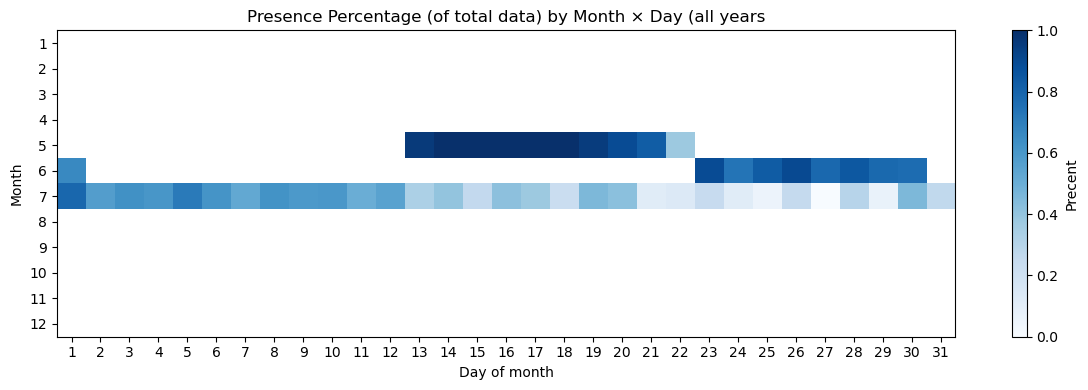

In [33]:
# Visualize month and day presence in heatmap - Percent Present over total data (present/present+absent)

# counts for presence 0/1 per (month, day)
ct = pd.crosstab(index=[brcr["month"], brcr["day"]], columns=brcr["presence"]).reindex(
    columns=[0, 1], fill_value=0
)

# presence proportion within each (month, day)
rate = (ct[1] / ct.sum(axis=1)).unstack("day").reindex(
    index=range(1, 13), columns=range(1, 32)
)

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(rate.values, aspect="auto", interpolation="nearest", cmap="Blues", vmin=0, vmax=1)

ax.set_yticks(np.arange(12))
ax.set_yticklabels(range(1, 13))
ax.set_xticks(np.arange(31))
ax.set_xticklabels(range(1, 32))
ax.set_xlabel("Day of month")
ax.set_ylabel("Month")
ax.set_title("Presence Percentage (of total data) by Month × Day (all years")

fig.colorbar(im, ax=ax, label="Precent")
plt.tight_layout()
plt.show()

findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.


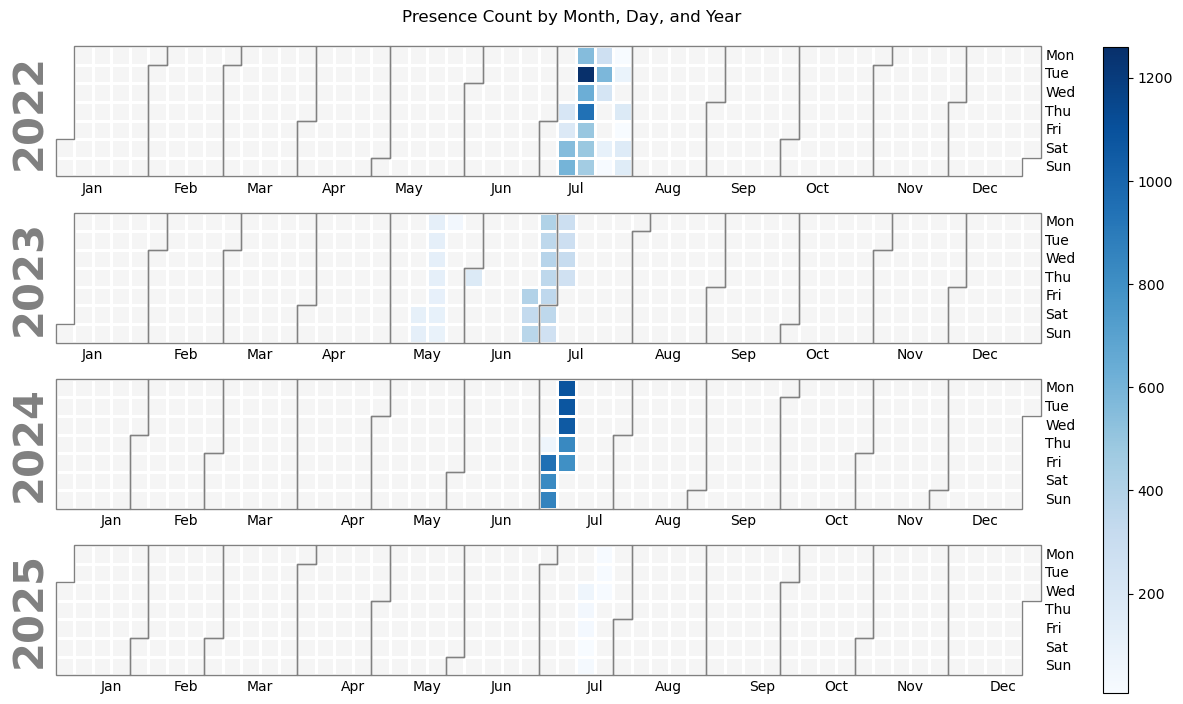

In [34]:
# Use datetime column to build calplot heatmap visual
brcr["date"] = pd.to_datetime(dict(year=brcr["year"], month=brcr["month"], day=brcr["day"]))

s = (brcr.query("presence == 1")
        .groupby("date")
        .size()
        .asfreq("D", fill_value=0))

calplot.calplot(s, cmap="Blues", colorbar=True, suptitle="Presence Count by Month, Day, and Year")
plt.show()

findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.


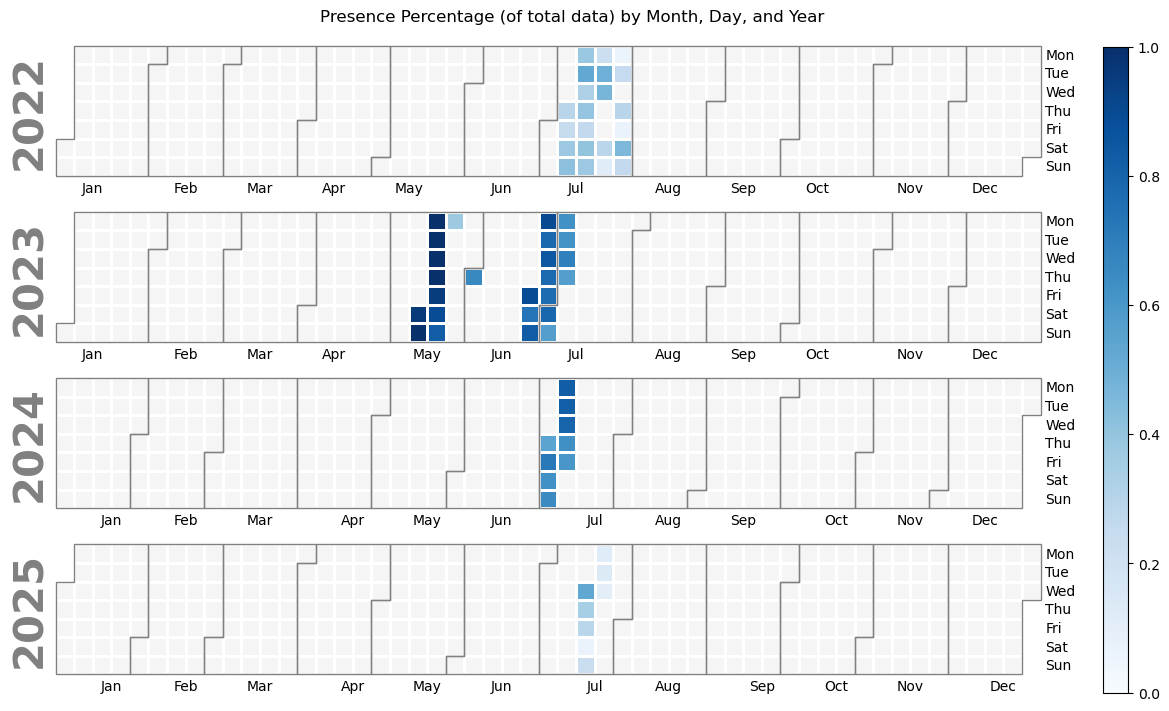

In [35]:
# Present percentages (of total data) by month, day, year
brcr["date"] = pd.to_datetime(dict(year=brcr["year"], month=brcr["month"], day=brcr["day"]))

# Presence rate per day = present / total
daily = brcr.groupby("date")["presence"]
rate = (daily.mean()                         # mean of 0/1 = proportion present
              .asfreq("D"))                  # include missing days as NaN (no data)
# If you prefer missing days to show 0 instead of NaN:
# rate = rate.fillna(0)

calplot.calplot(rate, cmap="Blues", colorbar=True, vmin=0, vmax=1,
                suptitle="Presence Percentage (of total data) by Month, Day, and Year")
plt.show()


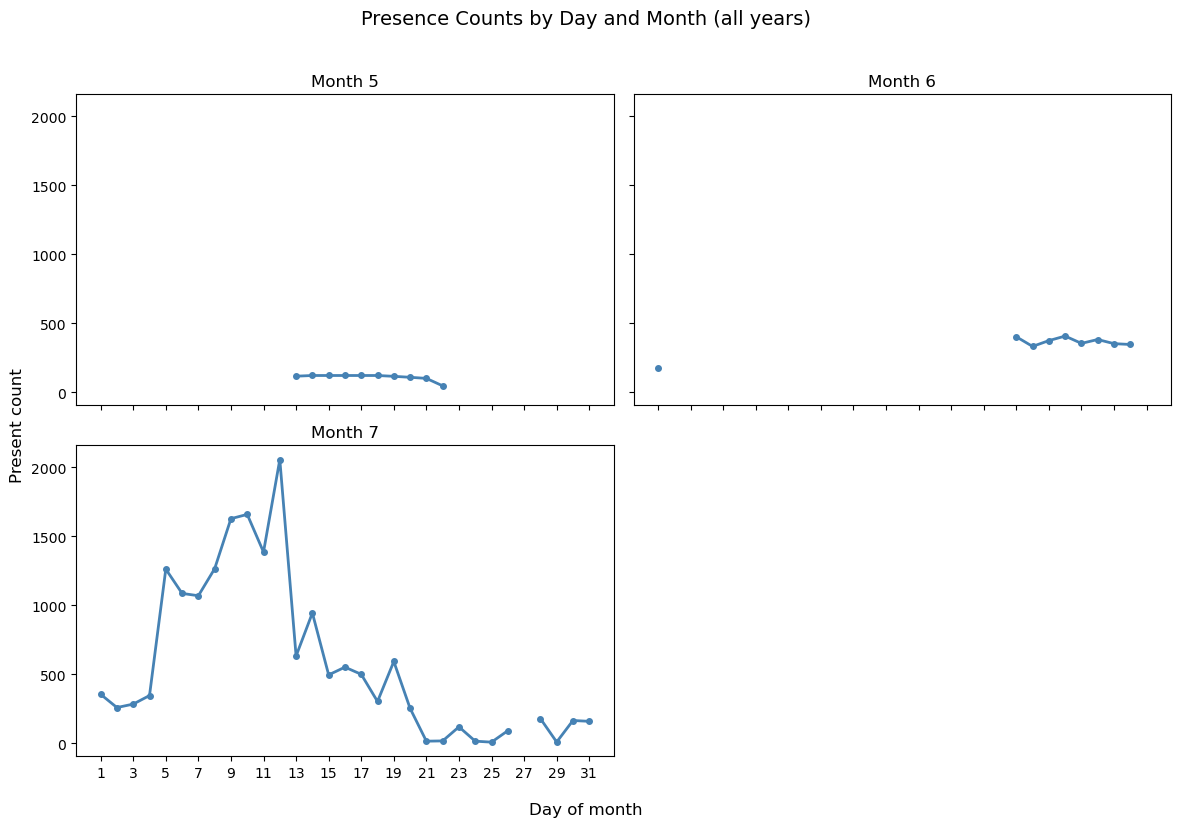

In [36]:
# Distribution of Presence counts by Day per month

present = (brcr.query("presence == 1")
           .groupby(["month", "day"])
           .size()
           .rename("Present_count")
           .unstack("month")
           .reindex(index=range(1, 32))   # missing -> NaN (NOT 0)
           .sort_index())

months = sorted(present.columns)

n = len(months)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4*nrows), sharex=True, sharey=True)
axes = axes.ravel() if hasattr(axes, "ravel") else [axes]

fig.suptitle("Presence Counts by Day and Month (all years)", fontsize=14, y=1.02)

for i, m in enumerate(months):
    ax = axes[i]
    ax.plot(present.index, present[m],
            linewidth=2, color="steelblue",
            marker="o", markersize=4)
    ax.set_title(f"Month {m}")
    ax.set_xticks([1,3,5,7,9,11,13,15,17,19,21,23,25,27,29,31])

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.supxlabel("Day of month")
fig.supylabel("Present count")
plt.tight_layout()
plt.show()

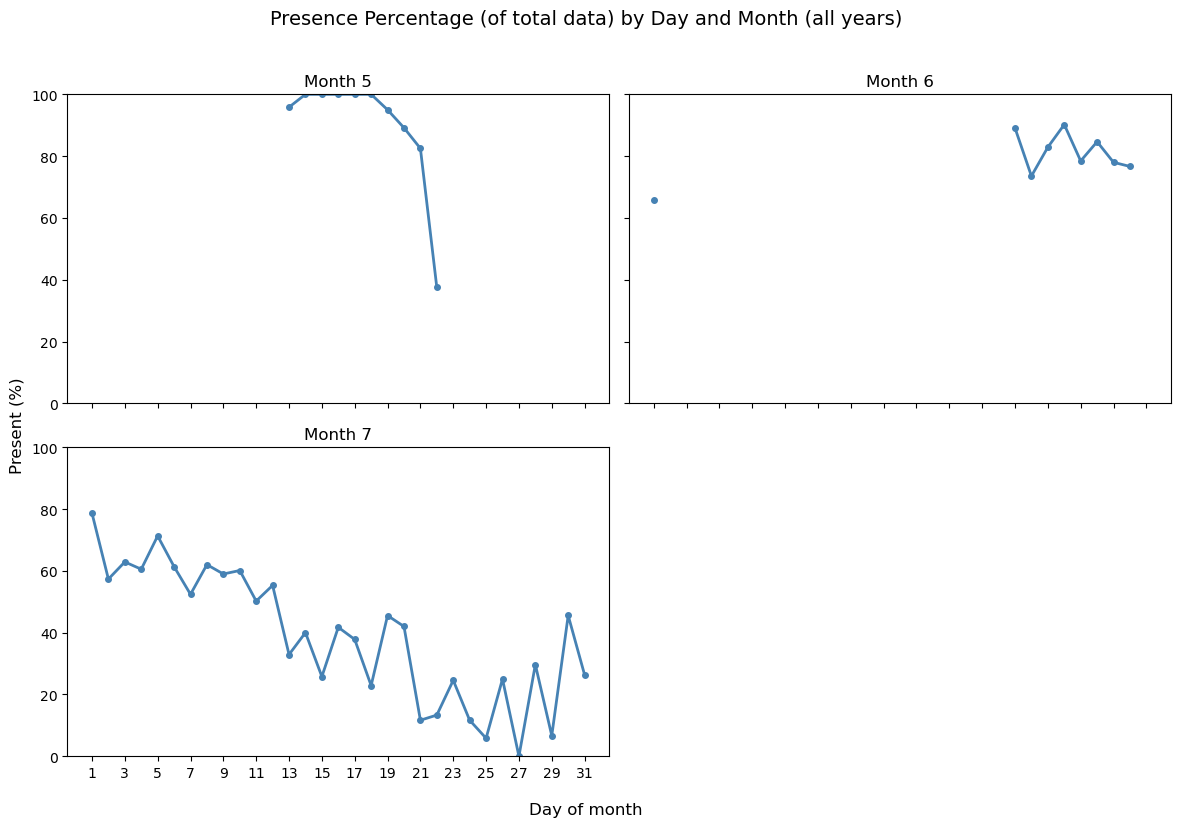

In [37]:
# Percentage of presence over total data

# --- counts per (month, day) for presence 0/1 ---
counts = (pd.crosstab(index=[brcr["month"], brcr["day"]], columns=brcr["presence"])
          .reindex(columns=[0, 1], fill_value=0)
          .rename(columns={0: "Absent", 1: "Present"}))

# --- presence percent within each (month, day): Present / (Absent+Present) * 100 ---
present_pct = (counts["Present"] / counts.sum(axis=1) * 100)

# matrix with rows=day, cols=month (for line plots by month)
present_pct = (present_pct
               .unstack("month")                          # columns = month, index = day
               .reindex(index=range(1, 32))               # ensure days 1..31
               #.reindex(index=range(1, 32), fill_value=0)
               .reindex(columns=sorted(brcr["month"].unique())))  # month order

# --- plot: one subplot per month ---
months = list(present_pct.columns)

n = len(months)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows), sharex=True, sharey=True)
axes = axes.ravel() if hasattr(axes, "ravel") else [axes]

fig.suptitle("Presence Percentage (of total data) by Day and Month (all years)", fontsize=14, y=1.02)

for i, m in enumerate(months):
    ax = axes[i]
    ax.plot(present_pct.index, present_pct[m],
        linewidth=2, color="steelblue",
        marker="o", markersize=4)    
    ax.set_title(f"Month {m}")
    ax.set_xticks([1,3,5,7,9,11,13,15,17,19,21,23,25,27,29,31])
    ax.set_ylim(0, 100)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.supxlabel("Day of month")
fig.supylabel("Present (%)")
plt.tight_layout()
plt.show()

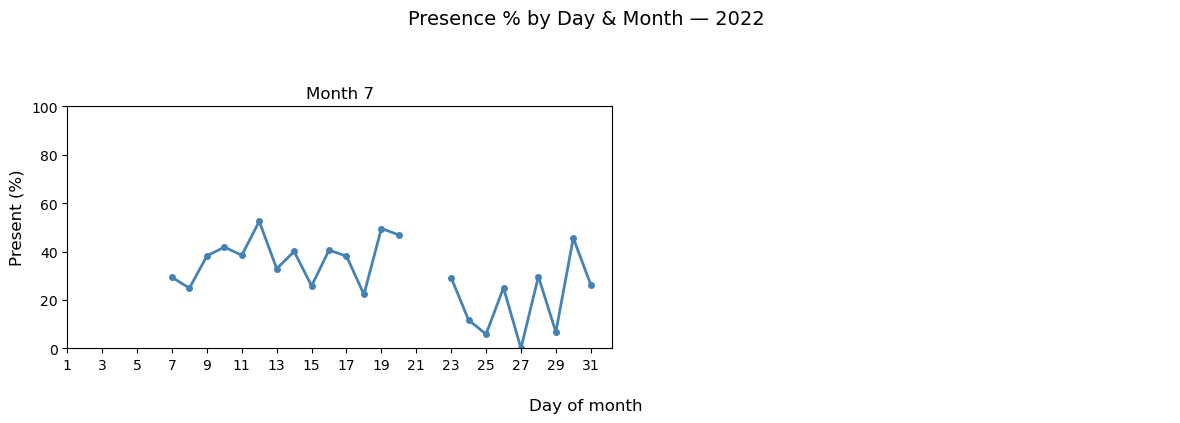

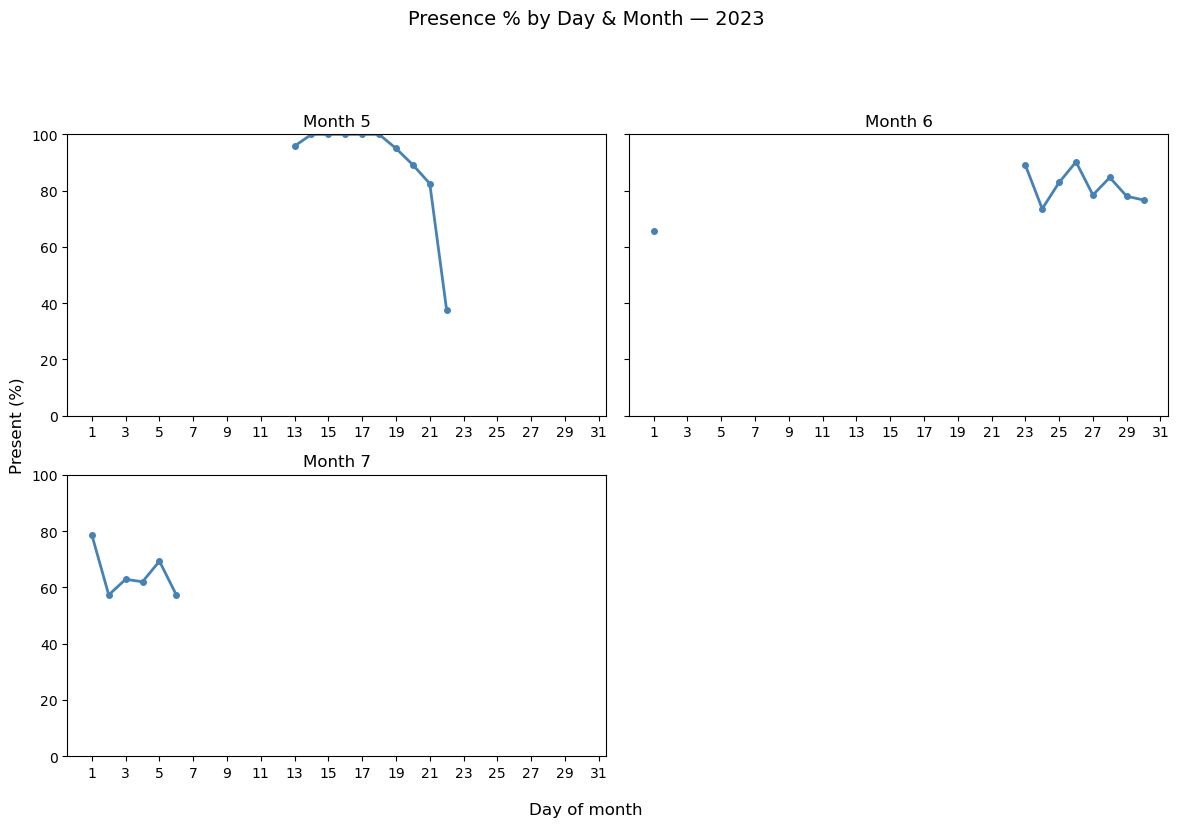

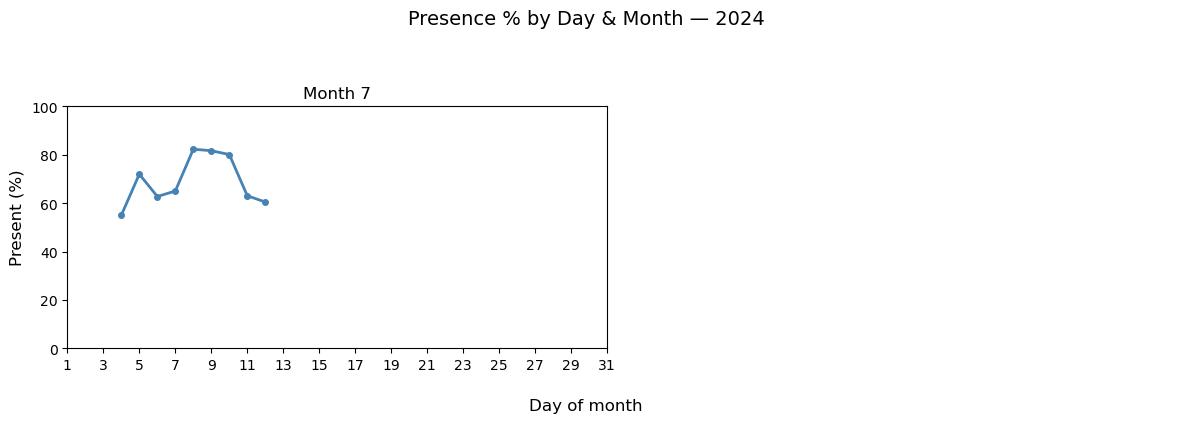

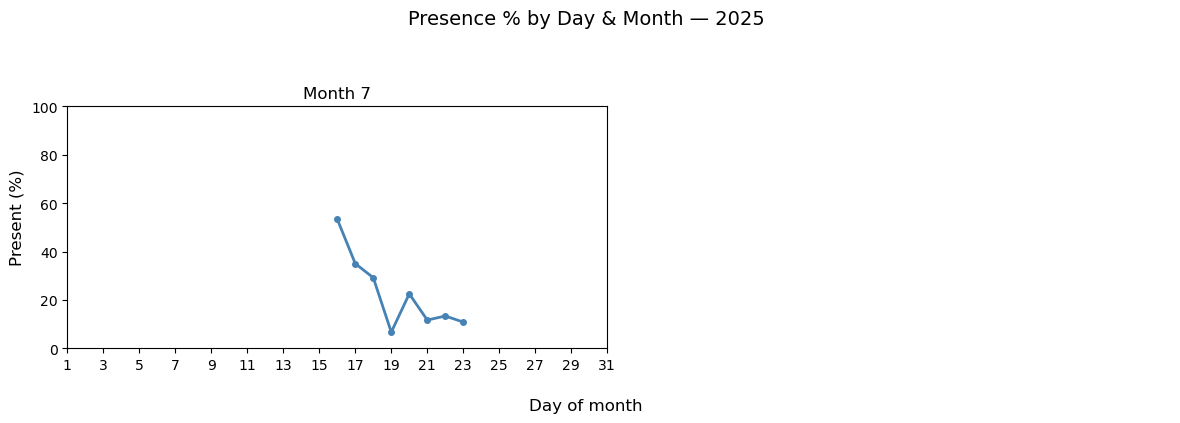

In [38]:
# Day-of-Month Presence Rate (%) — Monthly Panels per Year

# Ensure year/month/day exist (change "date" to your datetime column if needed)
if "year" not in brcr.columns:
    d = pd.to_datetime(brcr["date"], errors="coerce")
    brcr = brcr.assign(year=d.dt.year, month=d.dt.month, day=d.dt.day)

years = sorted(brcr["year"].dropna().unique())
months_all = sorted(brcr["month"].dropna().unique())

for y in years:
    dfi = brcr.loc[brcr["year"].eq(y)]

    counts = (pd.crosstab(index=[dfi["month"], dfi["day"]], columns=dfi["presence"])
              .reindex(columns=[0, 1], fill_value=0))

    den = counts.sum(axis=1)
    present_pct = (counts[1] / den.replace(0, np.nan) * 100)

    present_pct = (present_pct
                   .unstack("month")              # index=day, columns=month
                   .reindex(index=range(1, 32))
                   .reindex(columns=months_all))  # consistent month order across years

    months = [m for m in months_all if present_pct[m].notna().any()]  # only months with data that year

    n = len(months)
    ncols = 2
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4*nrows), sharex=True, sharey=True)
    axes = np.atleast_1d(axes).ravel()

    fig.suptitle(f"Presence % by Day & Month — {y}", fontsize=14, y=1.02)

    for i, m in enumerate(months):
        ax = axes[i]
        ax.plot(present_pct.index, present_pct[m],
                linewidth=2, color="steelblue",
                marker="o", markersize=4)
        ax.set_title(f"Month {m}")
        ax.set_xticks([1,3,5,7,9,11,13,15,17,19,21,23,25,27,29,31])
        ax.tick_params(axis="x", which="both", labelbottom=True)  # <-- force labels
        ax.set_ylim(0, 100)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.supxlabel("Day of month")
    fig.supylabel("Present (%)")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


### Presence by Site Per Year

In [41]:
brcr['site'].value_counts()

site
GroversCreek_West_Treat_GCPD            3780
GroversCreek_East_Treat_GCPE            3600
GroversCreek_GCP-H_Treat                3300
GroversCreek_GCP-G_Control              3300
GroversCreek_GCP-F_Treat                3300
EglonBeebe_Treat_EBE                    2640
EglonBeebe_Treat_EBW                    2640
EglonBebee_Control_EBC                  2640
JohnsonSouthSound_East_Treat_JSSE       2259
Klingel_Treat_KLIN                      2160
Klingel_Treat_BCCO                      2160
Klingel_Control_THEL                    2160
JohnsonSouthSound_West_Control_JSSW     2086
GroversCreek_East_Control_GCPB          1440
GroversCreek_West_Control_GCPC          1440
GroversCreek_East_Treat_GCPA            1440
BurleyCreek_Control_BCNO                 570
BurleyCreek_Treat_BCSO                   569
GroversCreek_East_Treat_GCPA_Initial     240
Name: count, dtype: int64

In [43]:
# Get all rows where 'site' exactly equals a specific name
johnson_Treat = brcr[brcr['site'] == 'JohnsonSouthSound_East_Treat_JSSE']
johnson_Treat.head(1)

,rec,presence,site,year,month,day,hour,minute,species,songtype,datetime,date
720,20220712_053000.p1.flac,1,JohnsonSouthSound_East_Treat_JSSE,2022,7,12,5,30,Certhia americana,Common Song,2022-07-12 05:30:00,2022-07-12


In [47]:
# Get all rows where 'site' exactly equals a specific name
johnson_Control = brcr[brcr['site'] == 'JohnsonSouthSound_West_Control_JSSW']
johnson_Control.head(1)

,rec,presence,site,year,month,day,hour,minute,species,songtype,datetime,date
2160,20220712_053000.WAV,1,JohnsonSouthSound_West_Control_JSSW,2022,7,12,5,30,Certhia americana,Common Song,2022-07-12 05:30:00,2022-07-12


In [45]:
johnson_Treat['presence'].value_counts()

presence
1    1318
0     941
Name: count, dtype: int64

In [51]:
johnson_Treat.groupby('year')['presence'].value_counts()

year  presence
2022  1           1246
      0            914
2023  1             72
      0             27
Name: count, dtype: int64

In [50]:
johnson_Control['presence'].value_counts()

presence
0    1211
1     875
Name: count, dtype: int64

In [52]:
johnson_Control.groupby('year')['presence'].value_counts()

year  presence
2022  0           1147
      1            773
2023  1            102
      0             64
Name: count, dtype: int64

C:\Users\haley\AppData\Local\Temp\ipykernel_11980\3149781990.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  johnson_Treat["date"] = pd.to_datetime(dict(year=johnson_Treat["year"], month=johnson_Treat["month"], day=johnson_Treat["day"]))
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.


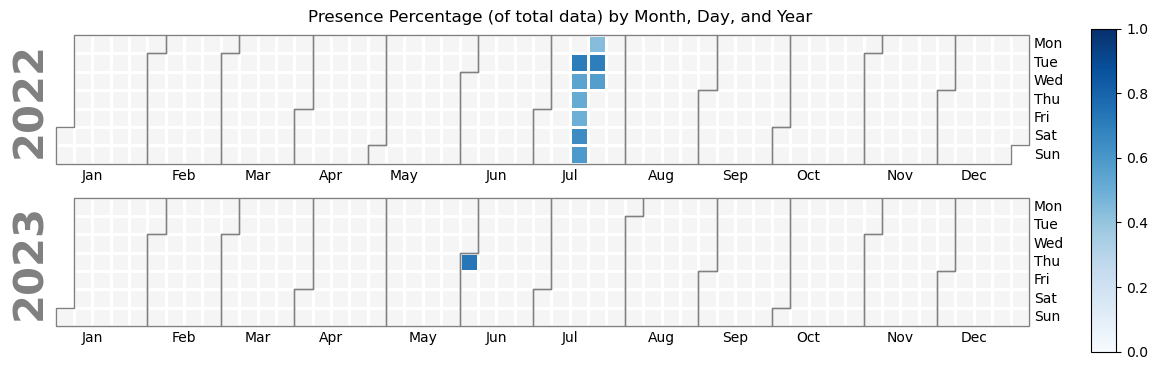

In [54]:
# Present percentages (of total data) by month, day, year
johnson_Treat["date"] = pd.to_datetime(dict(year=johnson_Treat["year"], month=johnson_Treat["month"], day=johnson_Treat["day"]))

# Presence rate per day = present / total
daily = johnson_Treat.groupby("date")["presence"]
rate = (daily.mean()                         # mean of 0/1 = proportion present
              .asfreq("D"))                  # include missing days as NaN (no data)
# If you prefer missing days to show 0 instead of NaN:
# rate = rate.fillna(0)

calplot.calplot(rate, cmap="Blues", colorbar=True, vmin=0, vmax=1,
                suptitle="Presence Percentage (of total data) by Month, Day, and Year")
plt.show()

C:\Users\haley\AppData\Local\Temp\ipykernel_11980\3119516008.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  johnson_Control["date"] = pd.to_datetime(dict(year=johnson_Control["year"], month=johnson_Control["month"], day=johnson_Control["day"]))
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.


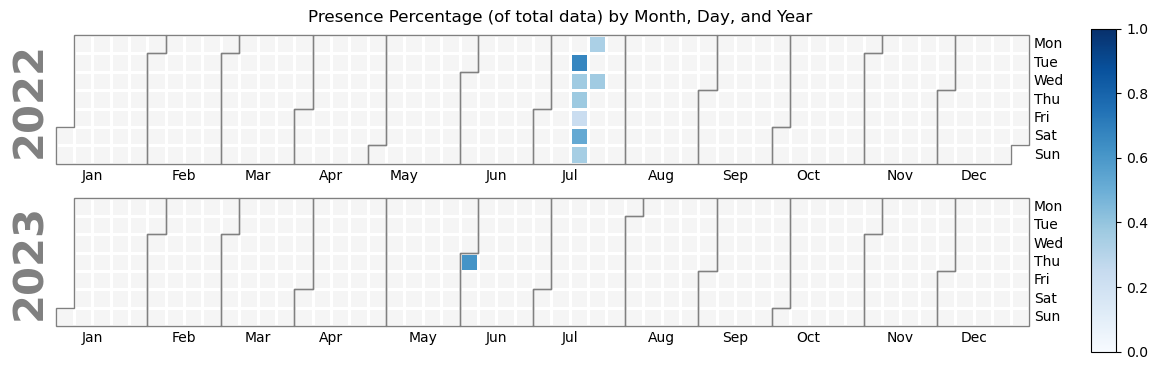

In [55]:
# Present percentages (of total data) by month, day, year
johnson_Control["date"] = pd.to_datetime(dict(year=johnson_Control["year"], month=johnson_Control["month"], day=johnson_Control["day"]))

# Presence rate per day = present / total
daily = johnson_Control.groupby("date")["presence"]
rate = (daily.mean()                         # mean of 0/1 = proportion present
              .asfreq("D"))                  # include missing days as NaN (no data)
# If you prefer missing days to show 0 instead of NaN:
# rate = rate.fillna(0)

calplot.calplot(rate, cmap="Blues", colorbar=True, vmin=0, vmax=1,
                suptitle="Presence Percentage (of total data) by Month, Day, and Year")
plt.show()

### To Do
- Presence vs Absence by site, by year/month/day
- Presence vs Absence by site, by time
- Explore number & type of species and songs
- Distribution & occurrence map across all teams/sites
- Organize control and treatment sites
- Explore time of occurrences, songs, songtypes. Does it change over seasons?
- Compare treatment and control sites, over time (aggregated treatment vs control, and individual level)
- Total number of recordings per site per year, month, day

In [39]:
# Number of sites that contain 'Control'
# Number of sites that contain 'Treat'
# Number of recordings per 'Control'
# Number of recordings per 'Treat'
# Sort